In [1]:
import sys
#sys.path.append('CPE883-2025-02/experiments/3W/tsdiffusion_transformed')
sys.path.append('/3W')
import os
#os.environ['path3W'] = '../../../'
import numpy as np
import pandas as pd
import torch
import importlib


In [ ]:
import debugpy


In [2]:
from loader import Loader3W
importlib.reload(sys.modules['loader'])
import toolkit
ld = Loader3W()

In [5]:
ld.get_ids_from_wells_with_event_type([8])
#ld.load_stats()
ld.extract_stats(['ABER-CKP', 'P-ANULAR', 'P-PDG','P-TPT','T-MON-CKP','T-PDG','T-TPT'])
ld.save_stats()

In [3]:
ld.load_stats()
dg = ld.preprocess(include_status_pred=True)

In [75]:

from tsdiffusion_transformed.ts_diffusion_transformed import TSDiffusion
importlib.reload(sys.modules['tsdiffusion_transformed.ts_diffusion_transformed'])
ts_diffusion = TSDiffusion(
    in_channels=17,
    hidden_dim=17*64,
    static_dim=7,
    num_steps=1000,
    status_dim=10,
    n_layers=2,
    lam=[0.15,0.7,0.1,0.05]
    )


/venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning:

enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True



In [ ]:
#debugpy.wait_for_client()
#ts_diffusion = ts_diffusion.to(device=torch.device('cuda'))
ts_diffusion.train3W(
    window_size=60,
    batch_size=250,
    epochs=15,
    status_pred_window=60*5,
    first_train = False,
    validate = False
)

Testing model...


In [ ]:

ts_diffusion.test3W(
    window_size=60,
    batch_size=250,
    status_pred_window=60*3
)

Test Loss: 428.776442
Test L1: 792.809510, Test L2: 1.971377, Test L3: 62.760080, Test L4: 0.011916


In [ ]:
ts_diffusion.save('ts_diffusion.pt')

In [34]:
ts_diffusion = ts_diffusion.load(
    'ts_diffusion.pt',
    in_channels=17,
    hidden_dim=17*32,
    static_dim=7,
    num_steps=1000,
    status_dim=10,
    n_layers=2,
    lam=[0.15,0.7,0.1,0.05]
    )
#ts_diffusion = ts_diffusion.to(device=torch.device('cuda'))
#ts_diffusion.save('state_ep5.pt')

In [ ]:
%matplotlib inline
ts_diffusion = ts_diffusion.to(device=torch.device('cuda'))
metrics = ts_diffusion.evaluate_datasets(
    test_datasets=2,
    window_size=60,
    batch_size=1000,
    missing_frac=0.1,     # igual ao seu test_impute
    sampling_steps=100
)

# 2) Plota
ts_diffusion.plot_metrics_matplotlib(metrics)

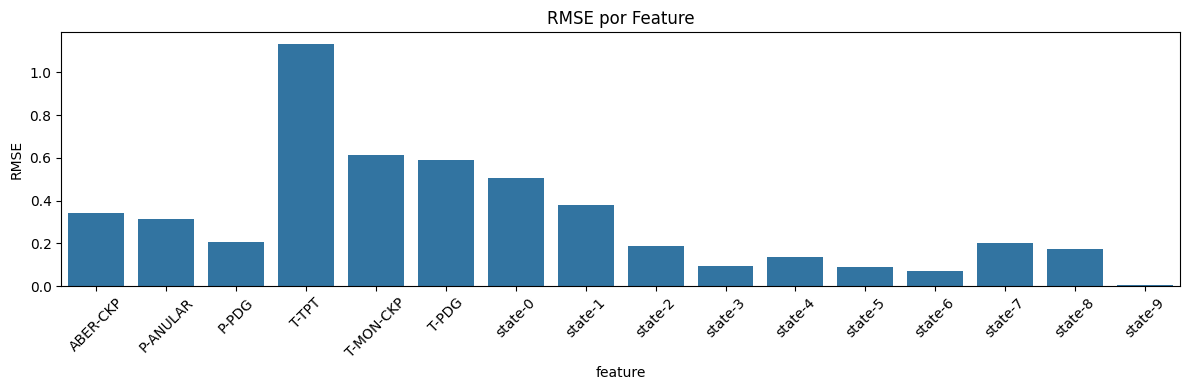

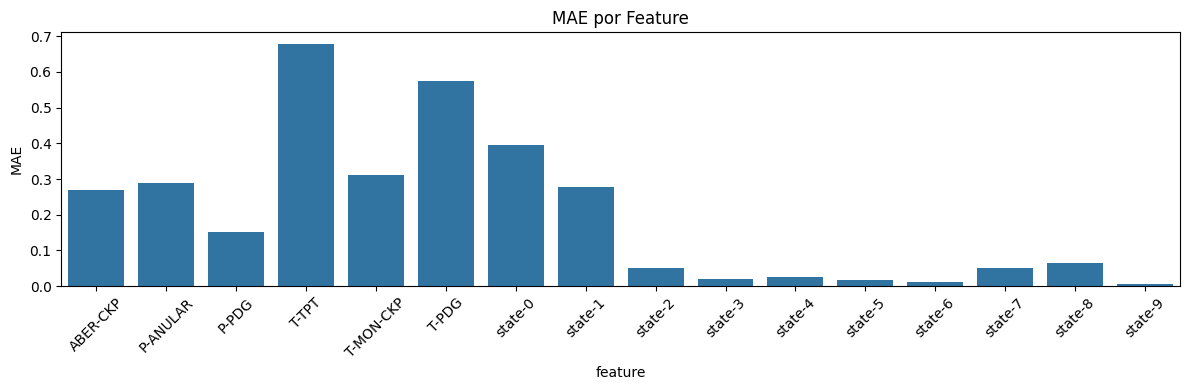

In [ ]:
%matplotlib inline
ts_diffusion = ts_diffusion.to(device=torch.device('cuda'))
metrics = ts_diffusion.evaluate_datasets(
    test_datasets=1,
    window_size=15,
    batch_size=1000,
    missing_frac=0.3,     # igual ao seu test_impute
    sampling_steps=300
)

# 2) Plota
ts_diffusion.plot_metrics_matplotlib(metrics)

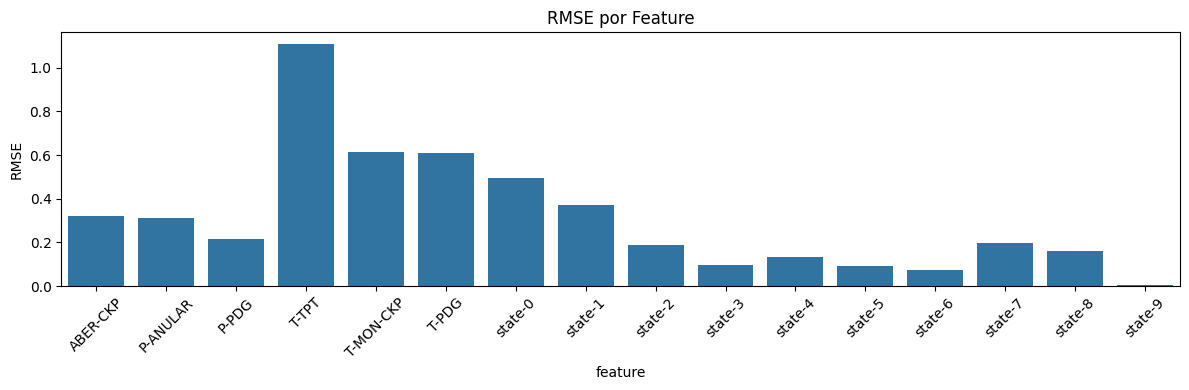

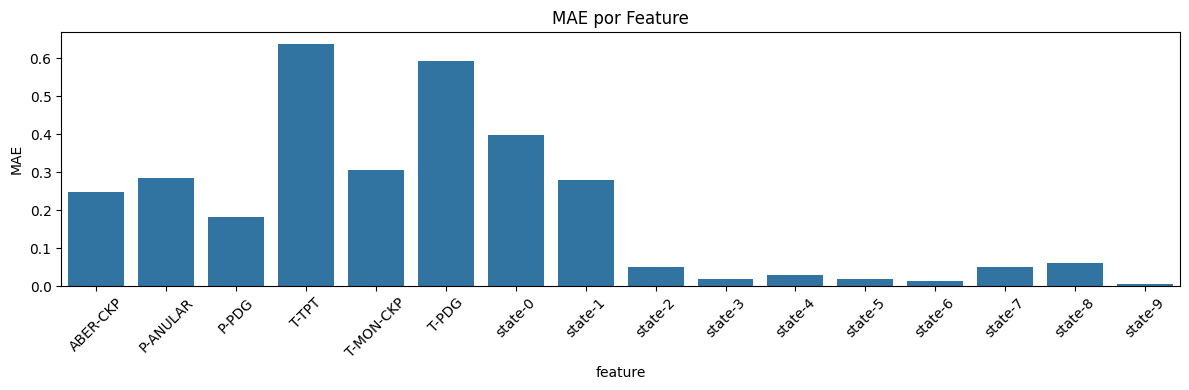

In [72]:
%matplotlib inline
ts_diffusion = ts_diffusion.to(device=torch.device('cuda'))
metrics = ts_diffusion.evaluate_datasets(
    test_datasets=1,
    window_size=15,
    batch_size=1000,
    missing_frac=0.3,     # igual ao seu test_impute
    sampling_steps=50
)

# 2) Plota
ts_diffusion.plot_metrics_matplotlib(metrics)